### Iris 데이터 시각화 실습
- 학습용 iris(붓꽃) 데이터를 로드하고 산점도 그래프로 시각화 해보기
- streamlit을 활용해 상호작용이 가능한 페이지 구현해보기

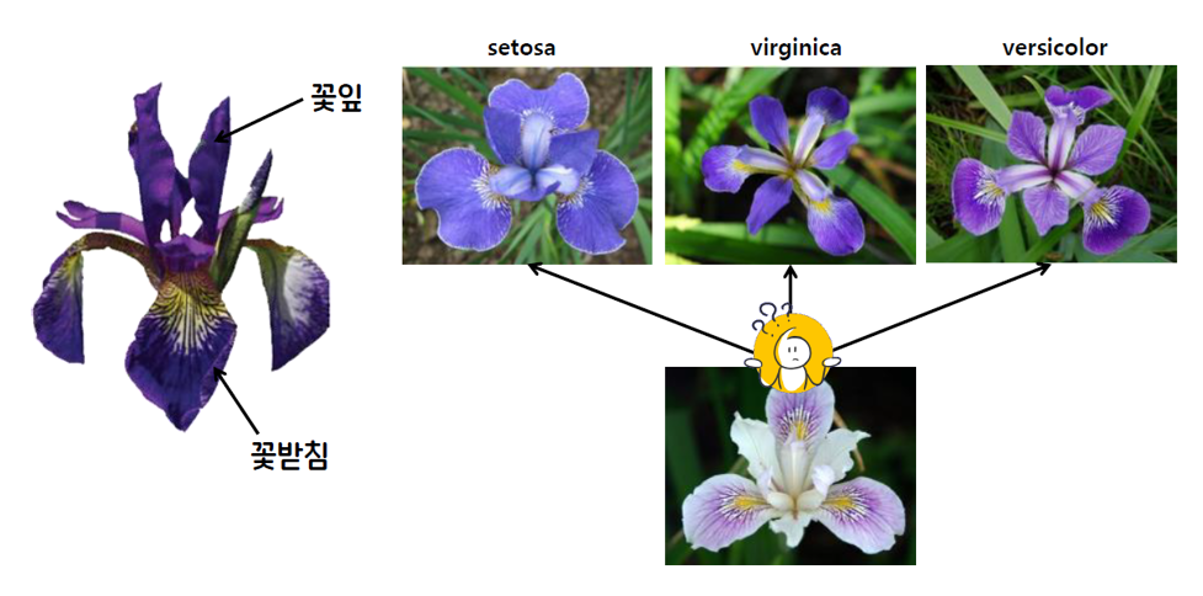

In [1]:
# seaborn에서 학습용 데이터 제공!
import seaborn as sns
df_iris = sns.load_dataset('iris')
df_iris

# sepal_length: 꽃받침 길이
# sepal_width: 꽃받침 너비
# petal_length: 꽃잎 길이
# petal_width: 꽃잎 너비
# species: 품종

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [2]:
df_iris['species'].unique()

array(['setosa', 'versicolor', 'virginica'], dtype=object)

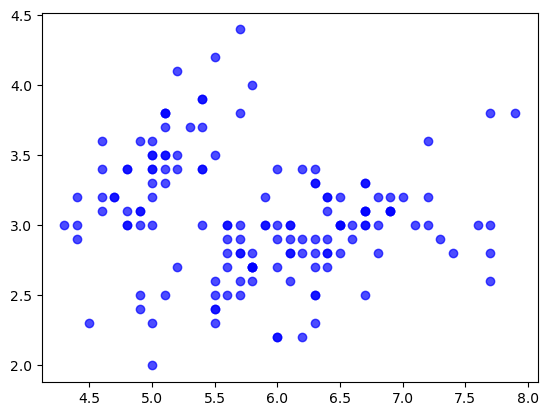

In [90]:
import matplotlib.pyplot as plt


# scatter: 산점도 그래프 출력 (두 특성간의 상관관계 파악할 때)
plt.scatter(df_iris['sepal_length'], df_iris['sepal_width'], # x, y축 
           color='blue',      # 색상
           alpha=0.7          # 투명도
           );

### Stramlit으로 시각화 출력

In [ ]:
%%writefile module/myApp19.py
import streamlit as st
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 메인 타이틀 (중앙쪽에 출력)
_, col, _ = st.columns([1,3,1])
col.header('Iris 데이터 시각화')
''
# iris 데이터 로드
df_iris = sns.load_dataset('iris')

# expander로 데이터 확인 공간 넣기
with st.expander('데이터 확인'):
    # height: DF의 출력 높이 설정
    st.dataframe(df_iris, height=300)

# 사이드바 부분
with st.sidebar:
    sel_x = st.selectbox('x축 특성 선택: ',
                        df_iris.columns[:-1], key=1
                        )
    ''
    sel_y = st.selectbox('y축 특성 선택: ',
                        df_iris.columns[:-1], key=2
                        )
    ''
    # sel_x, sel_y = st.multiselect('x, y축 특성', df_iris.columns[:-1])
    # 이렇게 써도 실행이 되긴 하는데... x, y축 선택할 때 순서를 생각해야 함..
    
    # 품종은 여러개를 선택할 수 있게 설정
    sel_species = st.multiselect('품종 선택: (:blue[**다중 선택 가능**])',
                                df_iris['species'].unique())
    ''
    # 투명도 설정 (0~1 사이 실수값으로 투명도 설정 가능! 0:투명 / 1:불투명)
    sel_alpha = st.slider('투명도(alpha) 설정:', 0.1, 1.0, 1.0)



# <선택된 값들로 산점도 차트 시각화>
# 품종 유형별로 차트에 표시될 색상을 다르게 지정
colors = {'setosa': 'red', 'versicolor':'blue', 'virginica': 'green'}

# 사용자가 사이드바에서 붓꽃 품종을 선택했을 경우
if sel_species:
    fig = plt.figure(figsize=(7, 5))
    plt.title('Iris Scatter Plot')

    # 사용자가 선택한 특성 및 품종에 따라 산점도 그래프를 반복 출력
    for i in sel_species:
        # 사용자가 선택한 품종 조건에 따라 df를 생성
        df = df_iris[df_iris['species']==i]
        plt.scatter(df[sel_x], df[sel_y],   # x, y축 데이터
           color = colors[i],                # 색상
           alpha = sel_alpha,                 # 투명도
           label = i                         # 점들의 이름, 나중에 legend가 이름을 모아서 표시함!!
           )
    plt.xlabel(sel_x)
    plt.ylabel(sel_y)
    plt.legend()
    st.pyplot(fig)

# 붓꽃의 품종이 선택되지 않았을 경우
else:
    st.warning('🪻 좌측 사이드바에서 품종을 선택해주세요!')

Overwriting module/myApp19.py


## 캐시 (Cache)
시간과 비용이 많이 들거나 자주 액세스 하는 계산 결과를 저장해두고,

응용프로그램이 실행될 때마다 **다시 계산할 필요 없이 저장된 결과를 출력**해주는 매커니즘(임시 저장소의 개념)
- streamlit에서는 @st.cache_data, @st.cache_resource 두 가지 코드로 사용자 정의 함수의 데코레이션 형태로 적용
    - **cache_data**: 데이터 객체를 반환해주는 함수에 적용 ex) DataFrame, array, list 등
    - **cache_resource**: 데이터보다 상대적으로 무거운 리소스를 반환하는 함수에 적용 ex) AI모델, DB연결 등
- 캐시로 데코레이션 된 함수가 호출되면 Streamlit은 이전과 동일한 매개변수로 호출되었는지 먼저 확인함
- 함수의 매개변수 혹은 코드가 변경되거나 세선이 종료(웹 브라우저 닫는 경우)되면 저장된 캐시를 삭제하고 함수를 재실행(매개변수나 코드의 변경이 없으면 저장된 값이 바로 반환되어 속도가 빠름)
- 캐시는 Streamlit 애플리케이션을 실행하는 시스템의 RAM에 임시 보관됨(캐시메모리) 

In [37]:
%%writefile module/myApp20.py
import streamlit as st
import pandas as pd
import time

st.title('Streamlit 캐시 실습✌️')

@st.cache_data
def cal_sum(a, b):
    time.sleep(5)
    return a + b

a = st.number_input('첫번째 숫자 입력', 0, 10, 1)
b = st.number_input('두번째 숫자 입력', 0, 10, 1)
''
# 계산 실행 버튼으로 함수 실행
if st.button('계산 실행 🧮', key=1):
    result = cal_sum(a, b)
    st.write(f'계산 결과 ▶ {result}')

# 캐시 삭제 버튼
if st.button('✔️ 전체 캐시 삭제', key=2):
    st.cache_data.clear()           # 현재 페이지에 있는 모든 캐시 삭제
    st.write('캐시 삭제 완! ')
''
'---'


@st.cache_data
def get_data(age):
    myDict = {'이름': '민정', '나이':age, '성별': '여'}
    df = pd.DataFrame(myDict, index=['회원정보'])
    time.sleep(3)
    return df

myAge = st.slider('나이 입력', 0, 100, 20)
''

if st.button('실행', key=3):
    result = get_data(myAge)
    st.write(result)

# 특정 함수만 캐시 삭제하기 (on_click에 함수명.clear)
if st.button('✔️ get_data 캐시 삭제', key=4, on_click=get_data.clear):
    get_data.clear()
    st.write('캐시 삭제 완!!')

Overwriting module/myApp20.py


## 폼 (Form)
위젯들을 그룹으로 묶어 여러 입력값을 받아서 저장해두며 **한 번에 제출하는 용도**로 활용
- 개별 위젯 값이 변경될 때마다 전체 코드가 재실행되는 비효율을 방지하고 여러 입력 위젯들을 그룹화 하기 위해 사용함
- 폼에서는 st.button이나 st.download_button은 사용할 수 없음
- 폼 내에서는 **st.form_submit_button**(최종 제출 버튼)이 하나 이상 포함되어야 함
- 최종 제출 버튼을 누르기 전에는 다른 값들의 초기화가 일어나지 않음
- 폼 안에 다른 폼을 넣을 수는 없음

In [93]:
%%writefile module/myApp21.py
import streamlit as st
import pandas as pd
import time

# 사용자 정의 함수 선언 및 캐시 적용
@st.cache_data
def get_data(name, age, gender):
    myDict = {'이름': name, '나이':age, '성별': gender}
    df = pd.DataFrame(myDict, index=['회원정보'])
    time.sleep(3)
    return df

# 폼 미적용 상태
name1 = st.text_input(label="**What's your name?**",
                     placeholder='이름을 입력하세요 ')
age1 = st.slider('How old are you?', 1, 100, 30)
gender1 = st.radio(label= 'What is your gender?',
                  options=['남', '여'])

st.write(get_data(name1, age1, gender1))

# strftime: 날짜 타입을 문자열로 변환
# %Y : 4자리 연도
# %m : 월
# %d : 일
st.write(f'현재 시각: {time.strftime('%H:%M:%S')}')
st.caption('⚠️값이 바뀔 때마다 전체 코드가 재실행됩니다.')

''
'---'

############ 폼 적용 ~~~~~~~~ ###############
# clear_on_submit=True : 제출 버튼을 누르면 기존 입력 내용들 초기화 (False는 그대로 있음 )
with st.form(key='Form1', clear_on_submit=True):
    name2 = st.text_input(label="**What's your name?**",
                     placeholder='이름을 입력하세요 ')
    age2 = st.slider('How old are you?', 1, 100, 30)
    gender2 = st.radio(label= 'What is your gender?',
                      options=['남', '여'])

    st.write(f'현재 시각: {time.strftime('%H:%M:%S')}')
    st.caption('⚠️값이 바뀌어도 최종 제출 전에는 코드 재실행 안 됩니당. 제출할 때마다 값은 초기화됩니다.')

    if st.form_submit_button('제출하기!'):
        st.write(get_data(name2, age2, gender2))


Overwriting module/myApp21.py


In [98]:
%%writefile module/myApp2100.py
import streamlit as st

with st.form('my'):
    a = st.number_input('1숫자', value=0)
    b = st.number_input('2숫자', value=0)

    bt = st.form_submit_button('계산하기')

if bt:
    st.write(a+b)

Overwriting module/myApp2100.py


## 세션 (Session)
- 사용자가 브라우저를 연 시점부터 닫을 때까지의 Streamlit과의 상호작용 단위
- Streamlit은 새로 동작(ex 위젯의 변화 등) 할 때마다 이전 값들이 초기화 되는데
- 초기화가 되지 않고 **변수의 상태를 유지**할 필요가 있을 때 세션을 통해 값을 지속시키기!
- **session_state**: 세션 상태를 관리하고 유지시키는 함수로, 웹 브라우저를 열고 있는 시간동안 지속되는 저장공간 객체로 딕셔너리처럼 사용할 수 있음
- 폼이 다수의 값을 입력받아 한 번에 제출하기 위한 용도였다면, 세션은 브라우저를 열고 있는 내내 특정값이 초기화 되지 않게 해줌  

In [2]:
%%writefile module/myApp22.py
import streamlit as st

st.header('🎈세션 사용법🎈')
st.write('세션에 아무 값도 없는 초기 상태: ', st.session_state)

# session_state 내에 'cnt'라는 키를 만들고 0으로 초기화
# [조건문과 not in을 사용한 이유]
# not in 없이 cnt값을 초기화시키는 코드를 작성하면
# 코드가 재실행 될때마다 이전 입력값을 무시하고 초기값으로 돌아가기 때문에
# 이를 방지하기 위해 첫 시작에만 동작할 수 있게 not in 사용

# 먼저 있나 확인하고 (없으면 만들기)
if 'cnt' not in st.session_state: # 딕셔너리 형태의 저장공간 객체
    st.session_state['cnt'] = 0


# 버튼이 들어갈 컬럼 설정
col1, col2, col3, _ = st.columns([1, 1, 1, 4])

# 증가, 감소, 초기화 버튼
# 버튼을 누르면 버튼에 지정된 key값도 session_state에 추가되며,
# 해당 key값을 가진 버튼을 누르면 value값이 True로 변경됨 
if col1.button('1 증가', key=1):
    st.session_state['cnt'] += 1

if col2.button('1 감소', key=2):
    st.session_state['cnt'] -= 1

if col3.button('초기화', key=3):
    st.session_state['cnt'] = 0

st.write('현재 카운트: ', st.session_state['cnt'])

''
'---'
''

# 폼과 세션 결합
st.header('세션으로 폼 상태 기억하기')

# # 버튼을 눌러서 폼을 보고 싶은 경우
# if st.button('폼 보이기', key=5):
#     with st.form(key='Form1', clear_on_submit=True):
#         name2 = st.text_input(label="**What's your name?**",
#                          placeholder='이름을 입력하세요 ')
#         age2 = st.slider('How old are you?', 1, 100, 30)
#         gender2 = st.radio(label= 'What is your gender?',
#                           options=['남', '여'])

#         if st.form_submit_button('제출하기'):
#             '제출 결과: '
#             st.write({'이름':name2, '나이':age2, '성별':gender2})
            
# =============================================================
# 버튼이 눌려졌다는 사실을 변수에 저장해두고 버튼이 눌린 상태(True)라면 화면을 보여주게
# 세션으로 그 상태를 관리하도록 코드를 작성

# 폼을 보여줄지 말지를 결정할 'form_open' 값을 세션에 False로 초기화 
if 'form_open' not in st.session_state:
    st.session_state['form_open'] = False

# 폼이 열려있는 상태(True)라면 폼을 보여줌
if st.session_state['form_open']:
    st.subheader('사용자 정보 입력')
    # 폼 생성
    with st.form(key='Form1', clear_on_submit=True):
        name = st.text_input('이름 입력')
        age = st.slider('나이', 20,60,30)
        gender = st.radio('성별', ['남', '여'])

        if st.form_submit_button('제출하기'):
            st.success(f'제출 완료: {age}세, {gender}, {name}님!')

    #폼 닫기 버튼
    if st.button('폼 닫기'):
        st.session_state['form_open'] = False
        st.rerun()
        
# 폼이 닫혀있는 상태(False)라면 '폼 보이기' 버튼을 보여줌
else:
    st.info('아래 버튼을 누르면 입력 양식이 나타납니다')
    if st.button('폼 보이기'):
        # 버튼을 누르면 세션의 'form_open'이 True가 되어 if문이 실행되게 설정됨
        st.session_state['form_open'] = True
        st.rerun()
        

Overwriting module/myApp22.py


# Streamlit 유저 인증
- Streamlit이 웹 애플리케이션과 연동되어 사용되기 때문에 사용자 인증(로그인 등)에 대한 부분도 생각해줘야 함
- Streamlit에서 유저 인증을 쉽게 도와주는 streamlit-authenticator 패키지를 활용
- 참조 깃허브: https://github.com/mkhorasani/Streamlit-Authenticator

In [66]:
!pip install streamlit-authenticator

   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ----------------------- ---------------- 1.3/2.3 MB 6.5 MB/s eta 0:00:01
   ---------------------------------------- 2.3/2.3 MB 5.5 MB/s  0:00:00

   -------------------------- ------------- 2/3 [streamlit-authenticator]
   ---------------------------------------- 3/3 [streamlit-authenticator]



### 유저 정보를 저장하기 위한 yaml 파일 생성
- yaml 파일은 모든 프로그래밍 언어와 함께 사용할 수 있고, 사람이 읽기 쉬운 표준 데이터 표현 형식 중 하나로 주로 데이터를 저장하기 위해 사용됨
- 딕셔너리 형태의 계층 구조로 구성되어 있음
- Streamlit에서 유저 인증을 위한 유저 정보를 yaml 파일로 관리함

In [68]:
# yaml 파일 생성 예시
import yaml

data = {'credentials': 
           {'usernames': 
               {'hgd': {'email': 'gdhong@mail.com',
                        'name': '홍길동',
                        'password': 'mypwd'},
                'lss': {'email': 'ssyi@mail.com',
                        'name': '이순신',
                        'password': 'mypwd'}}},
        'cookie': {'expiry_days': 30, 
                   'key': 'abcd', 
                   'name': 'myCookie'},
        }

with open('data/test.yaml', 'w', encoding='utf-8') as f:
    # dump : 파일로 저장
    # sort_keys=False : 딕셔너리에 보여지는 순서대로 저장 (True면 key값을 abc순으로 정렬)
    # allow_unicode=True : yaml 파일 내부에 문자 그대로 저장 (False면 유니코드로 저장)
    yaml.dump(data, f, sort_keys=False, allow_unicode=True)

In [71]:
# yaml 파일 불러오기
with open('data/test.yaml', 'r', encoding='utf-8') as f:
    temp = yaml.safe_load(f)           # safe_load: 파일 로드하기
temp

{'credentials': {'usernames': {'hgd': {'email': 'gdhong@mail.com',
    'name': '홍길동',
    'password': 'mypwd'},
   'lss': {'email': 'ssyi@mail.com', 'name': '이순신', 'password': 'mypwd'}}},
 'cookie': {'expiry_days': 30, 'key': 'abcd', 'name': 'myCookie'}}

## 1) 패스워드 데이터를 해시로 암호화
- 보안 강화를 위해 패스워드를 그냥 텍스트로 저장해두는 것이 아니라 해시함수를 사용해서 암호화
- **hash 함수**: 임의의 크기의 입력을 받아 고정 크기의 바이트 문자열을 반환하는 수학적 알고리즘으로 암호화 알고리즘의 기본 형태
- 해시함수는 반환된 문자열로 원래의 입력을 복원할 수 없는 **일방향성**을 가지고 있으며, 개인정보보호법 30조에 의거해 서비스 사용자의 PW는 일방향 암호화가 필수적으로 적용되어야 함
- 즉, 사용자의 ID, PW를 그대로 저장해두는 것이 아니라 해시값으로 변환하여 저장하고 시스템에 접근할 때 저장된 해시값과 새롭게 입력된 ID, PW의 해시값을 비교하여 일치하면 접근 허용하는 방식으로 동작

In [75]:
# 해싱을 위한 bcrypt 패키지 임포트
import bcrypt

# 해싱 전 패스워드
pwds =['123', 'abc']

# 해시 암호화를 실행 후 리스트에 담기
 # hashpw : 해시된 비밀번호 생성
 # encode : 인코딩 (문자를 바이트로)
 # gensalt : 솔트(임의의 값) 생성 - 같은ㅇ비밀번호를 쓰더라도 사용자마다 다르게 생성
 # decode : 디코딩 (바이트를 문자로)
hashed_pwds = [bcrypt.hashpw(i.encode(), bcrypt.gensalt()).decode() for i in pwds]

print('생성된 해시 비밀번호')
for p, hp in zip(pwds, hashed_pwds):
    print(f'평문 {p} -> 해시 {hp}')

생성된 해시 비밀번호
평문 123 -> 해시 $2b$12$HY0Pxa1L6oZt7EpnRu6IBeROcArF1BdSD3J7ZpsZ5yYSil8goUUnq
평문 abc -> 해시 $2b$12$prwWw98j3x5r8WdLIaNAEOHPLMtLzz18pUHLz9TcvxMB8IEK3Yib.


## 2) 해싱된 암호로 yaml 파일 생성

In [76]:
data = {'credentials': 
           {'usernames': 
               {'hgd': {'email': 'gdhong@mail.com',
                        'name': '홍길동',
                        'password': '$2b$12$HY0Pxa1L6oZt7EpnRu6IBeROcArF1BdSD3J7ZpsZ5yYSil8goUUnq'},
                'lss': {'email': 'ssyi@mail.com',
                        'name': '이순신',
                        'password': '$2b$12$prwWw98j3x5r8WdLIaNAEOHPLMtLzz18pUHLz9TcvxMB8IEK3Yib.'}}},
        'cookie': {'expiry_days': 30, 
                   'key': 'abcd', 
                   'name': 'myCookie'},
        }

# streamlit에서 로그인 기능을 구현하기 위해서는 지정된 key값들(email, name, password)들이 데이터에 포함되어 있어야 함

# yaml 파일 생성
with open('data/config.yaml', 'w', encoding='utf-8') as f:
    yaml.dump(data, f, sort_keys=False, allow_unicode=True)

## 3) 유저 인증 streamlit 대시보드 생성 

In [18]:
%%writefile module/myApp23.py
import streamlit as st
import streamlit_authenticator as stauth
import yaml
import time

# 1. config.yaml 파일 불러오기 (사용자 정보 데이터)
with open('data/config.yaml', 'r', encoding='utf-8') as f:
    config = yaml.safe_load(f)

# 2. authenticator 객체 생성 (불러온 yaml 파일의 정보를 객체에 입력)
authenticator = stauth.Authenticate(
    config['credentials'],
    config['cookie']['name'],
    config['cookie']['key'],
    config['cookie']['expiry_days']
)

#  3. 로그인 위젯 생성
authenticator.login(
    # 
    location='main',
    #
    fields={'Form name': '사용자 정보 입력',
            'Username': '사용자 ID',
            'Password': '사용자 PW',
            'Login': '로그인'},
     key = 'login_btn')


# 4. 세션 확인
st.write(st.session_state)
# login 함수 실행시 자독으로 세션에 생성되는 변수들
 # authentication_status: 로그인 상태 변수
 #                      (None: 로그인 전, True: 로그인 성공, False: 로그인 실패)
 # username: 로그인에 성공한 사용자의 ID
 # name: 로그인에 성공한 실제 사용자 이름
 # logout: 로그아웃 상태 변수
 # init: streamlit이 웹과 통신하며 보안을 유지하거나 통계를 내기 위해 사용하는 내부 값


# 5. 로그인 상태에 따른 메인화면 구성
 # 1) 로그인 성공 시
if st.session_state['authentication_status'] : 
    # 로그인후 세션 확인
    # st.write(st.session_state)

    # 환영 문구 및 로그아웃 버튼 배치
    col1, col2 = st.columns([12, 2])

    with col1:
        st.write(f'환영합니다! :blue[**{st.session_state['name']}**]님 🫡')
    with col2:
        # 로그아웃 버튼
        authenticator.logout(
            button_name='로그아웃',
            location='main',
            key='logout_bnt'
        )

    '---'

    st.title('메인 대시보드')
    st.write('여기에 메인 컨텐츠 작성~~!')
        
# 5.패스워드 변경 기능
    with st.expander('🔒비밀번호 변경하기') :
        try :
            # 변경 폼에 정보를 입력하고 변경을 눌렀을 경우!
            # reset_password : 비밀번호 변경 폼 위젯 생성
            if authenticator.reset_password(
                # 사용자 이름 설정
                st.session_state['username'],
                # 위젯에 보여지는 텍스트 설정
                fields={'Form name':'비밀번호 변경',
                        'Current password':'현재 비밀번호',
                        'New password':'새 비밀번호',
                        'Repeat password':'재입력',
                        'Reset':'변경'
                       },
                key='reset_btn'
            ) :
                # 변경된 비밀번호를 yaml 파일에 저장
                # (다음번 로그인에 변경된 비밀번호가 유지)
                with open('data/config.yaml', 'w', encoding='utf-8') as f :
                    yaml.dump(config, f, sort_keys=False, allow_unicode=True)

                st.success('비밀번호가 변경되었습니다. 다시 로그인해주세요.')
                    
                with st.spinner('2초 후 자동 로그아웃 됩니다.') :
                    time.sleep(2)
                    st.session_state['authentication_status'] = None
                    st.rerun()
            
        except Exception as e :
            st.error(e)
# Tnstls123.
    
    
 # 2) 로그인 실패 시
elif st.session_state['authentication_status'] is False:
    st.error('아이디 또는 비밀번호가 일치하지 않습니다.')
    
 # 3) 로그인 전 (초기화면) 
elif st.session_state['authentication_status'] is None:
    st.info('로그인이 필요한 서비스입니다.')




Overwriting module/myApp23.py
